In [14]:
from shorkie import Shorkie
import json
import random
import torch

with open("data/shorkie_params.json") as f:
    config = json.load(f)

model = Shorkie.from_tf_checkpoint(config["model"], "data/checkpoint_f0.h5")
model.eval()

BASES = "ACGT"
BASE_TO_IDX = {b: i for i, b in enumerate(BASES)}


def one_hot_encode(seq: str) -> torch.Tensor:
    t = torch.zeros(4, len(seq))
    for i, ch in enumerate(seq):
        t[BASE_TO_IDX[ch], i] = 1.0
    return t


def random_dna_sequence(length: int) -> str:
    return "".join(random.choices(BASES, k=length))


sequences = torch.stack([one_hot_encode(random_dna_sequence(16384)) for _ in range(5)])

with torch.no_grad():
    y = model(sequences)  # (5, 896, 5215)

print(f"{y.shape=}")

y.shape=torch.Size([5, 896, 5215])


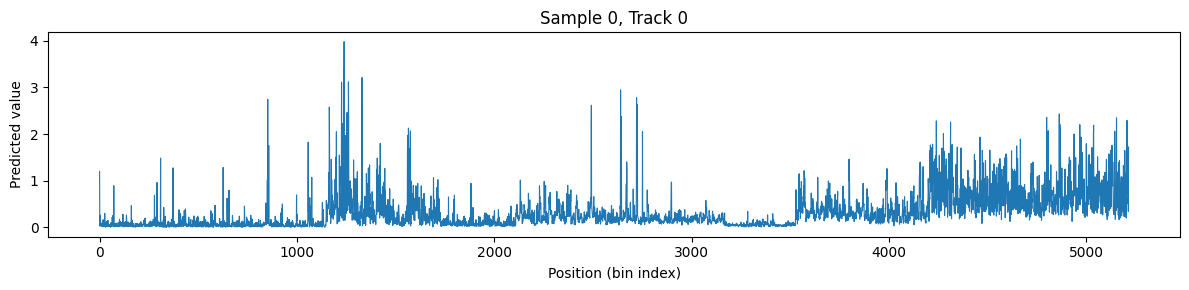

In [16]:
import matplotlib.pyplot as plt

track = y[0, 0, :].numpy()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(track, linewidth=0.8)
ax.set_xlabel("Position (bin index)")
ax.set_ylabel("Predicted value")
ax.set_title("Sample 0, Track 0")
fig.tight_layout()
plt.show()